<a href="https://colab.research.google.com/github/Mirajul100/Machine-Learning/blob/master/Emotions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
import re

In [3]:
df = pd.read_csv('/content/train.txt' , sep=';' , header=None , names=['text' , 'emotion'])

In [4]:
df.head(5)

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [5]:
df.shape

(16000, 2)

In [6]:
df.isnull().sum()

,0
text,0
emotion,0


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
encode = LabelEncoder()

In [10]:
encode.fit(df['emotion'])

LabelEncoder()

In [11]:
df['emotion'] = encode.transform(df['emotion'])

In [12]:
df.head(5)

,text,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0


# Convert text into lowercase

In [13]:
df['text'] = df['text'].str.lower()

In [14]:
df.head(5)

,text,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0


# Remove punctuations

In [15]:
df['text'] = df['text'].str.replace('[^\w\s]' , '' , regex=True)

# Remove digits

In [16]:
def remove_digits(text):
  new = ''
  for i in text:
    if not i.isdigit():
      new = new + i
  return new

In [17]:
df['text'] = df['text'].apply(remove_digits)

# Remove emojis

In [18]:
def remove_emoji(text):
  new = ''
  for i in text:
    if i.isascii():
      new = new + i
  return new

In [19]:
df['text'] = df['text'].apply(remove_emoji)

# Remove link

In [20]:
import re

In [21]:
def remove_link(text):
  return re.sub(r'http\S+' , '' , text)

In [22]:
df['text'] = df['text'].apply(remove_link)

# Remove html tags

In [23]:
def remove_tags(text):
 text = re.sub(r'<.*?>', '', text)
 return text

In [24]:
df['text'] = df['text'].apply(remove_tags)

# Remove stop words

In [25]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [26]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [27]:
stop_words = set(stopwords.words('english'))
len(stop_words)

198

In [28]:
def remove_stopwords(text):
 word = word_tokenize(text)
 new = []
 for i in word:
   if i not in stop_words:
     new.append(i)
 return ' '.join(new)

In [29]:
df['text'] = df['text'].apply(remove_stopwords)

In [30]:
df.head(5)

,text,emotion
0,didnt feel humiliated,4
1,go feeling hopeless damned hopeful around some...,4
2,im grabbing minute post feel greedy wrong,0
3,ever feeling nostalgic fireplace know still pr...,3
4,feeling grouchy,0


### Distribution of Emotion Labels

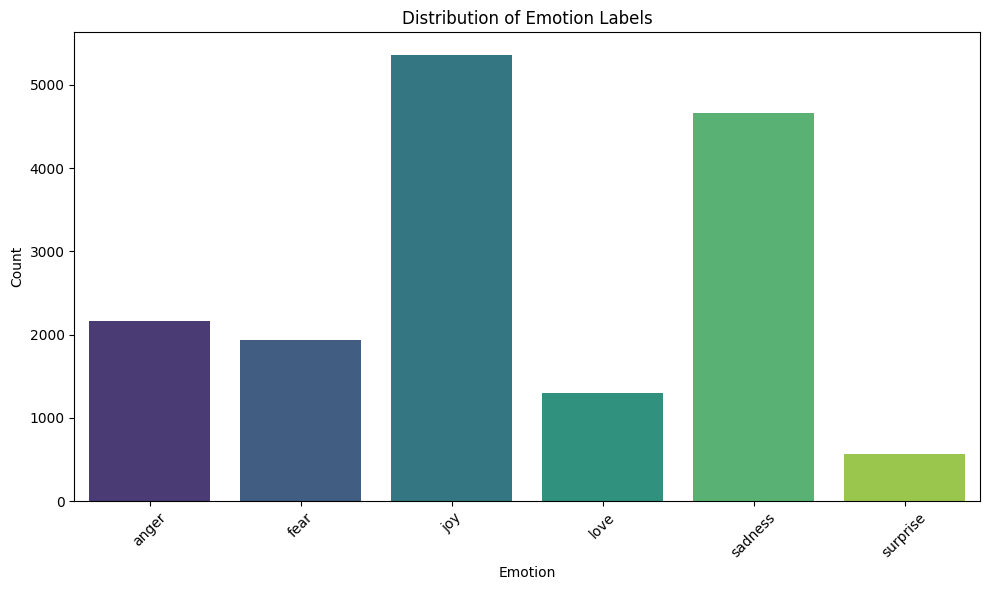

In [31]:
emotion_counts = df['emotion'].value_counts().sort_index()
emotion_labels = encode.inverse_transform(emotion_counts.index)

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_labels, y=emotion_counts.values, palette='viridis')
plt.title('Distribution of Emotion Labels')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
X = df['text']
y = df['emotion']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [35]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [36]:
model_nb = MultinomialNB()
model_nb.fit(X_train_bow, y_train)

MultinomialNB()

In [37]:
y_pre_bow = model_nb.predict(X_test_bow)
acc = accuracy_score(y_test , y_pre_bow)
print(acc)

0.7649621212121213


In [38]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [39]:
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [40]:
y_pre_tfidf = model_nb.predict(X_test_tfidf)
acc = accuracy_score(y_test , y_pre_tfidf)
print(acc)

0.6609848484848485


In [41]:
model_lo = LogisticRegression(C= 10, penalty= 'l2', solver= 'liblinear')
model_lo.fit(X_train_bow, y_train)

LogisticRegression(C=10, solver='liblinear')

In [42]:
y_pre_bow = model_lo.predict(X_test_bow)
acc = accuracy_score(y_test , y_pre_bow)
print(acc)

0.8916666666666667


### Save the best performing model and its vectorizer

In [43]:
import pickle

with open('logistic_regression_bow_model.pkl', 'wb') as f:
    pickle.dump(model_lo, f)
with open('count_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)

print("Logistic Regression model and CountVectorizer saved successfully.")

Logistic Regression model and CountVectorizer saved successfully.


In [44]:
model_lo = LogisticRegression(C= 10, penalty= 'l2', solver= 'liblinear')
model_lo.fit(X_train_tfidf, y_train)

LogisticRegression(C=10, solver='liblinear')

In [45]:
y_pre_tfidf = model_lo.predict(X_test_tfidf)
acc = accuracy_score(y_test , y_pre_tfidf)
print(acc)

0.8856060606060606


In [46]:
from sklearn.model_selection import GridSearchCV

In [47]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

In [48]:
grid = GridSearchCV(
    estimator=model_lo,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [49]:
grid.fit(X_train_bow, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.883955223880597


In [50]:
grid.fit(X_train_tfidf, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.8737873134328359


In [51]:
from xgboost import XGBClassifier

In [52]:
model_xg = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [53]:
model_xg.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [54]:
y_pre_tfidf = model_xg.predict(X_test_tfidf)
acc = accuracy_score(y_test , y_pre_tfidf)
print(acc)

0.75625
